# NBA Analysis Project for Python Bootcamp at KEDGE Business School MSc DAB Program
**Created by Delabriliano Ismail and Quentin Belaud**

**October 2025** 

In [137]:
import pandas as pd

# Importing Main Dataset

## Box Score Dataset

In [138]:
dfbs1 = pd.read_csv('regular_season_box_scores_2010_2024_part_1.csv')
dfbs2 = pd.read_csv('regular_season_box_scores_2010_2024_part_2.csv')
dfbs3 = pd.read_csv('regular_season_box_scores_2010_2024_part_3.csv')

In [139]:
dflist = [dfbs1, dfbs2, dfbs3]

if all([set(dflist[0].columns) == set(df.columns) for df in dflist]):
    print('All Columns Names are the same')
else:
    print('Different Columns Name')

All Columns Names are the same


In [140]:
df = pd.concat(dflist, ignore_index=True)

### Data Understanding

1. **season_year**: The year of the basketball season.
2. **game_date**: The date of the game.
3. **gameId**: Unique identifier for the game.
4. **teamId**: Unique identifier for the team.
5. **teamCity**: The city where the team is based.
6. **teamName**: The name of the team.
7. **teamTricode**: A three-letter code representing the team.
8. **teamSlug**: A unique identifier for the team.
9. **personId**: Unique identifier for the person (player).
10. **personName**: The name of the person (player).
11. **position**: The position of the player.
12. **comment**: Any additional comments or notes.
13. **jerseyNum**: The jersey number of the player.
14. **minutes**: The number of minutes played by the player.
15. **fieldGoalsMade**: The number of field goals made by the player.
16. **fieldGoalsAttempted**: The number of field goals attempted by the player.
17. **fieldGoalsPercentage**: The shooting percentage for field goals.
18. **threePointersMade**: The number of three-pointers made by the player.
19. **threePointersAttempted**: The number of three-pointers attempted by the player.
20. **threePointersPercentage**: The shooting percentage for three-pointers.
21. **freeThrowsMade**: The number of free throws made by the player.
22. **freeThrowsAttempted**: The number of free throws attempted by the player.
23. **freeThrowsPercentage**: The shooting percentage for free throws.
24. **reboundsOffensive**: The number of offensive rebounds by the player.
25. **reboundsDefensive**: The number of defensive rebounds by the player.
26. **reboundsTotal**: The total number of rebounds by the player.
27. **assists**: The number of assists by the player.
28. **steals**: The number of steals by the player.
29. **blocks**: The number of blocks by the player.
30. **turnovers**: The number of turnovers by the player.
31. **foulsPersonal**: The number of personal fouls committed by the player.
32. **points**: The total number of points scored by the player.
33. **plusMinusPoints**: The plus-minus statistic for the player, indicating the team's score differential when the player is on the court.

In [141]:
Describe = []

for i in df.columns:
    Describe.append([
        i,
        df[i].dtypes,
        df[i].notnull().sum(),
        df[i].isna().sum(),
        round((df[i].isna().sum() / len(df)) * 100, 2),
        df[i].nunique(),
    ])

pd.DataFrame(data = Describe,
columns = [
    'Columns',
    'DataType',
    'Non-Null',
    'Null',
    'NullPercentage',
    'Unique',
])

,Columns,DataType,Non-Null,Null,NullPercentage,Unique
0,season_year,object,424478,0,0.00,14
1,game_date,object,424478,0,0.00,2210
2,gameId,int64,424478,0,0.00,16658
3,matchup,object,424478,0,0.00,1972
4,teamId,int64,424478,0,0.00,30
5,teamCity,object,424478,0,0.00,31
6,teamName,object,424478,0,0.00,31
7,teamTricode,object,424478,0,0.00,32
8,teamSlug,object,424478,0,0.00,31
9,personId,int64,424478,0,0.00,1731


## Shooting Dataset

In [142]:
dfth_1 = pd.read_csv('NBA_2010_Shots.csv')
dfth_2 = pd.read_csv('NBA_2011_Shots.csv')
dfth_3 = pd.read_csv('NBA_2012_Shots.csv')
dfth_4 = pd.read_csv('NBA_2013_Shots.csv')
dfth_5 = pd.read_csv('NBA_2014_Shots.csv')
dfth_6 = pd.read_csv('NBA_2015_Shots.csv')
dfth_7 = pd.read_csv('NBA_2016_Shots.csv')
dfth_8 = pd.read_csv('NBA_2017_Shots.csv')
dfth_9 = pd.read_csv('NBA_2018_Shots.csv')
dfth_10 = pd.read_csv('NBA_2019_Shots.csv')
dfth_11 = pd.read_csv('NBA_2020_Shots.csv')
dfth_12 = pd.read_csv('NBA_2021_Shots.csv')
dfth_13 = pd.read_csv('NBA_2022_Shots.csv')
dfth_14 = pd.read_csv('NBA_2023_Shots.csv')
dfth_15 = pd.read_csv('NBA_2024_Shots.csv')

In [143]:
dflist = [dfth_1, dfth_2, dfth_3, dfth_4, dfth_5, dfth_6, dfth_7, dfth_8, dfth_9, dfth_10, dfth_11, dfth_12, dfth_13, dfth_14, dfth_15]


if all([set(dflist[0].columns) == set(df.columns) for df in dflist]):
    print('All Columns Names are the same')
else:
    print('Different Columns Name')

All Columns Names are the same


In [144]:
dfth = pd.concat(dflist, ignore_index=True)

### Data Understanding

- Self-Explanatory:
**TEAM_NAME**, **PLAYER_NAME**, **POSITION_GROUP**, **POSITION**, **HOME_TEAM**, **AWAY_TEAM**

1. **SEASON_1** & **SEASON_2**: Season indicator variables
2. **TEAM_ID**: NBA's unique ID variable of that specific team in their API.
3. **PLAYER_ID**: NBA's unique ID variable of that specific player in their API.
4. **GAME_DATE**: Date of the game (M-D-Y // Month-Date-Year).
5. **GAME_ID**: NBA's unique ID variable of that specific game in their API.
6. **EVENT_TYPE**: Character variable denoting a shot outcome (Made Shot // Missed Shot).
7. **SHOT_MADE**: True/False variable denoting a shot outcome (True // False).
8. **ACTION_TYPE**: Description of shot type (layup, dunk, jump shot, etc.).
9. **SHOT_TYPE**: Type of shot (2PT or 3PT).
10. **BASIC_ZONE**: Name of the court zone the shot took place in. Restricted Area, In the Paint (non-RA), Midrange, Left Corner 3, Right Corner 3, Above the Break, Backcourt.
12. **ZONE_NAME**: Name of the side of court the shot took place in. left, left side center, center, right side center, right
13. **ZONE_ABB**: Abbreviation of the side of court. (L), (LC), (C), (RC), (R).
14. **ZONE_RANGE**: Distance range of shot by zones. Less than 8 ft., 8-16 ft. 16-24 ft. 24+ ft.
15. **LOC_X**: X coordinate of the shot in the x, y plane of the court (0, 50).
16. **LOC_Y**: Y coordinate of the shot in the x, y plane of the court (0, 50).
17. **SHOT_DISTANCE**: Distance of the shot with respect to the center of the hoop, in feet.
18. **QUARTER**: Quarter of the game.
19. **MINS_LEFT**: Minutes remaining in the quarter.
20. **SECS_LEFT**: Seconds remaining in minute of the quarter.

In [145]:
Describe = []

for i in dfth.columns:
    Describe.append([
        i,
        dfth[i].dtypes,
        dfth[i].notnull().sum(),
        dfth[i].isna().sum(),
        round((dfth[i].isna().sum() / len(dfth)) * 100, 2),
        dfth[i].nunique(),
    ])

pd.DataFrame(data = Describe,
columns = [
    'Columns',
    'DataType',
    'Non-Null',
    'Null',
    'NullPercentage',
    'Unique',
])

,Columns,DataType,Non-Null,Null,NullPercentage,Unique
0,SEASON_1,int64,3053916,0,0.00,15
1,SEASON_2,object,3053916,0,0.00,15
2,TEAM_ID,int64,3053916,0,0.00,30
3,TEAM_NAME,object,3053916,0,0.00,34
4,PLAYER_ID,int64,3053916,0,0.00,1748
5,PLAYER_NAME,object,3053916,0,0.00,1753
6,POSITION_GROUP,object,3045986,7930,0.26,3
7,POSITION,object,3045986,7930,0.26,16
8,GAME_DATE,object,3053916,0,0.00,2374
9,GAME_ID,int64,3053916,0,0.00,17884


# Data Wrangling
To prepare the dataset for analysis, we performed data wrangling steps including name normalization, alias correction, dataset merging, and column cleanup. These transformations ensured consistency and improved the usability of key features like player position, height, and weight.

## Shooting Dataset

### Duplicates

In [146]:
dfth.duplicated().sum()

100

We can see above that there are 100 duplicates exist on the dataframe. To ensure, let's see the duplicate row and check if they are really
having duplicate value with another row

In [147]:
dfth[dfth.duplicated(keep=False)]

,SEASON_1,SEASON_2,TEAM_ID,TEAM_NAME,PLAYER_ID,PLAYER_NAME,POSITION_GROUP,POSITION,GAME_DATE,GAME_ID,HOME_TEAM,AWAY_TEAM,EVENT_TYPE,SHOT_MADE,ACTION_TYPE,SHOT_TYPE,BASIC_ZONE,ZONE_NAME,ZONE_ABB,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT
44262,2010,2009-10,1610612766,Charlotte Bobcats,101109,Raymond Felton,G,PG,03-10-2010,20900953,PHI,CHA,Missed Shot,False,Layup Shot,2PT Field Goal,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.25,0,4,9,55
44289,2010,2009-10,1610612766,Charlotte Bobcats,101109,Raymond Felton,G,PG,03-10-2010,20900953,PHI,CHA,Missed Shot,False,Layup Shot,2PT Field Goal,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.25,0,4,9,55
45102,2010,2009-10,1610612758,Sacramento Kings,201956,Omri Casspi,F,SF,03-10-2010,20900961,SAC,TOR,Missed Shot,False,Tip Shot,2PT Field Goal,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.25,0,2,8,50
45107,2010,2009-10,1610612758,Sacramento Kings,201956,Omri Casspi,F,SF,03-10-2010,20900961,SAC,TOR,Missed Shot,False,Tip Shot,2PT Field Goal,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.25,0,2,8,50
72415,2010,2009-10,1610612763,Memphis Grizzlies,201960,DeMarre Carroll,F,SF,02-16-2010,20900785,MEM,PHX,Missed Shot,False,Layup Shot,2PT Field Goal,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.25,0,4,9,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3023078,2024,2023-24,1610612741,Chicago Bulls,203083,Andre Drummond,C,C,03-18-2024,22300986,CHI,POR,Missed Shot,False,Tip Layup Shot,2PT Field Goal,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.25,0,1,0,6
3027459,2024,2023-24,1610612766,Charlotte Hornets,1641706,Brandon Miller,F,SF,01-12-2024,22300541,SAS,CHA,Missed Shot,False,Tip Layup Shot,2PT Field Goal,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.25,0,1,9,5
3027460,2024,2023-24,1610612766,Charlotte Hornets,1641706,Brandon Miller,F,SF,01-12-2024,22300541,SAS,CHA,Missed Shot,False,Tip Layup Shot,2PT Field Goal,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.25,0,1,9,5
3048046,2024,2023-24,1610612737,Atlanta Hawks,203991,Clint Capela,C,C,12-02-2023,22300286,MIL,ATL,Missed Shot,False,Tip Layup Shot,2PT Field Goal,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.25,0,2,0,1


We can see that the duplicated rows are really a duplicate with same players, shooting the same type in the same game and seconds, which are not possible. So we will drop the duplicated rows.

In [148]:
dfth.drop_duplicates(inplace=True)

In [149]:
Describe = []

for i in dfth.columns:
    Describe.append([
        i,
        dfth[i].dtypes,
        dfth[i].mode()[0],
        dfth[i].notnull().sum(),
        dfth[i].isna().sum(),
        round((dfth[i].isna().sum() / len(dfth)) * 100, 2),
        dfth[i].nunique(),
        dfth[i].drop_duplicates().sample(2).values
    ])

pd.DataFrame(data = Describe,
columns = [
    'Columns',
    'DataType',
    'Mode',
    'Non-Null',
    'Null',
    'NullPercentage',
    'Unique',
    'Unique Sample'
])

,Columns,DataType,Mode,Non-Null,Null,NullPercentage,Unique,Unique Sample
0,SEASON_1,int64,2019,3053816,0,0.00,15,"[2015, 2021]"
1,SEASON_2,object,2018-19,3053816,0,0.00,15,"[2016-17, 2020-21]"
2,TEAM_ID,int64,1610612744,3053816,0,0.00,30,"[1610612739, 1610612740]"
3,TEAM_NAME,object,Golden State Warriors,3053816,0,0.00,34,"[Toronto Raptors, Cleveland Cavaliers]"
4,PLAYER_ID,int64,201566,3053816,0,0.00,1748,"[1631093, 1631106]"
5,PLAYER_NAME,object,Russell Westbrook,3053816,0,0.00,1753,"[Deng Adel, Mustafa Shakur]"
6,POSITION_GROUP,object,G,3045886,7930,0.26,3,"[F, C]"
7,POSITION,object,SG,3045886,7930,0.26,16,"[PG-SG, SG-PG]"
8,GAME_DATE,object,04-09-2023,3053816,0,0.00,2374,"[03-23-2017, 03-16-2010]"
9,GAME_ID,int64,22000000,3053816,0,0.00,17884,"[21600563, 21500790]"


### Null Value

In [150]:
dfth.isna().sum()[dfth.isnull().sum() > 0]

POSITION_GROUP    7930
POSITION          7930
dtype: int64

After concatenating the 15 seasons of shot‑level data into a single dataset, we identified 7,930 rows (~0.26% of all shots) that were missing POSITION and POSITION_GROUP. Because they represent an insignificant fraction of the total sample and would not materially affect league‑wide trends, we removed them at this stage to ensure a clean and consistent dataset for subsequent analysis.

In [151]:
dfth = dfth.dropna(subset=['POSITION_GROUP','POSITION'])

## Box Score Dataset

### Duplication

In [152]:
df.duplicated().sum()

0

### Null Value

In [153]:
df.isnull().sum()[df.isnull().sum() > 0]

position     257898
comment      351473
jerseyNum    424478
minutes       73005
dtype: int64

The jerseyNum field is entirely empty and provides no analytical value. We remove it to streamline the dataset.

In [154]:
df.drop(columns='jerseyNum', inplace=True)
df.isnull().sum()

season_year                     0
game_date                       0
gameId                          0
matchup                         0
teamId                          0
teamCity                        0
teamName                        0
teamTricode                     0
teamSlug                        0
personId                        0
personName                      0
position                   257898
comment                    351473
minutes                     73005
fieldGoalsMade                  0
fieldGoalsAttempted             0
fieldGoalsPercentage            0
threePointersMade               0
threePointersAttempted          0
threePointersPercentage         0
freeThrowsMade                  0
freeThrowsAttempted             0
freeThrowsPercentage            0
reboundsOffensive               0
reboundsDefensive               0
reboundsTotal                   0
assists                         0
steals                          0
blocks                          0
turnovers     

We will now analyze whether players with missing values in the minutes column made significant contributions, using standard basketball metrics such as rebounds, assists, steals, blocks, and points.

In [155]:
missing_minutes_df = df[df['minutes'].isna()]
missing_stats = {
    'Rebounds': missing_minutes_df['reboundsTotal'].sum(),
    'Assists': missing_minutes_df['assists'].sum(),
    'Steals': missing_minutes_df['steals'].sum(),
    'Blocks': missing_minutes_df['blocks'].sum(),
    'Points': missing_minutes_df['points'].sum()
}

total_stats = {
    'Rebounds': df['reboundsTotal'].sum(),
    'Assists': df['assists'].sum(),
    'Steals': df['steals'].sum(),
    'Blocks': df['blocks'].sum(),
    'Points': df['points'].sum()
}

impact = {
    stat: round((missing_stats[stat] / total_stats[stat]) * 100, 2)
    for stat in missing_stats
}

for stat in impact:
    print(f"{stat}: {missing_stats[stat]} out of {total_stats[stat]} → {impact[stat]}% from missing-minute rows")

Rebounds: 0 out of 1447376 → 0.0% from missing-minute rows
Assists: 0 out of 779057 → 0.0% from missing-minute rows
Steals: 0 out of 253990 → 0.0% from missing-minute rows
Blocks: 0 out of 162550 → 0.0% from missing-minute rows
Points: 0 out of 3532813 → 0.0% from missing-minute rows


Missing values in the minutes column indicate players who did not participate in the game. These rows are excluded to focus the analysis on active players.

In [156]:
df.dropna(subset='minutes', inplace=True)
df.isnull().sum()

season_year                     0
game_date                       0
gameId                          0
matchup                         0
teamId                          0
teamCity                        0
teamName                        0
teamTricode                     0
teamSlug                        0
personId                        0
personName                      0
position                   184893
comment                    351473
minutes                         0
fieldGoalsMade                  0
fieldGoalsAttempted             0
fieldGoalsPercentage            0
threePointersMade               0
threePointersAttempted          0
threePointersPercentage         0
freeThrowsMade                  0
freeThrowsAttempted             0
freeThrowsPercentage            0
reboundsOffensive               0
reboundsDefensive               0
reboundsTotal                   0
assists                         0
steals                          0
blocks                          0
turnovers     

In [157]:
df['comment'].unique()

array([nan], dtype=object)

The comment field is incomplete and only explains player absences. Since this information is redundant after filtering non-playing rows, we remove it.

In [158]:
df.drop(columns='comment', inplace=True)
df.isnull().sum()

season_year                     0
game_date                       0
gameId                          0
matchup                         0
teamId                          0
teamCity                        0
teamName                        0
teamTricode                     0
teamSlug                        0
personId                        0
personName                      0
position                   184893
minutes                         0
fieldGoalsMade                  0
fieldGoalsAttempted             0
fieldGoalsPercentage            0
threePointersMade               0
threePointersAttempted          0
threePointersPercentage         0
freeThrowsMade                  0
freeThrowsAttempted             0
freeThrowsPercentage            0
reboundsOffensive               0
reboundsDefensive               0
reboundsTotal                   0
assists                         0
steals                          0
blocks                          0
turnovers                       0
foulsPersonal 

In [159]:
Describe = []

for i in df.columns:
    Describe.append([
        i,
        df[i].dtypes,
        df[i].mode()[0],
        df[i].notnull().sum(),
        df[i].isna().sum(),
        round((df[i].isna().sum() / len(df)) * 100, 2),
        df[i].nunique(),
        df[i].drop_duplicates().sample(2).values
    ])

pd.DataFrame(data = Describe,
columns = [
    'Columns',
    'DataType',
    'Mode',
    'Non-Null',
    'Null',
    'NullPercentage',
    'Unique',
    'Unique Sample'
])

,Columns,DataType,Mode,Non-Null,Null,NullPercentage,Unique,Unique Sample
0,season_year,object,2023-24,351473,0,0.00,14,"[2016-17, 2010-11]"
1,game_date,object,2024-04-14,351473,0,0.00,2210,"[2018-11-20, 2017-02-16]"
2,gameId,int64,22000700,351473,0,0.00,16658,"[21600893, 21900514]"
3,matchup,object,SAS @ MEM,351473,0,0.00,1972,"[MIN vs. NOH, HOU vs. UTA]"
4,teamId,int64,1610612759,351473,0,0.00,30,"[1610612753, 1610612766]"
5,teamCity,object,Los Angeles,351473,0,0.00,31,"[Milwaukee, New York]"
6,teamName,object,Spurs,351473,0,0.00,31,"[Grizzlies, Knicks]"
7,teamTricode,object,SAS,351473,0,0.00,32,"[OKC, MIA]"
8,teamSlug,object,spurs,351473,0,0.00,31,"[magic, pistons]"
9,personId,int64,201942,351473,0,0.00,1708,"[202714, 1628973]"


To fill missing values in the position column, we merge supplementary player data from a secondary dataset.

## NBA Player Statistic Dataset

In [160]:
df2 = pd.read_csv('NBA_PLAYERS.csv')

In [161]:
df2.duplicated().sum()

0

In [162]:
df2.describe().T

,count,mean,std,min,25%,50%,75%,max
Debut,5313.0,1990.347638,23.304513,1947.0,1971.0,1992.0,2012.0,2025.0
Final,5313.0,1994.583474,23.984924,1947.0,1975.0,1998.0,2017.0,2025.0
Height,5313.0,78.028421,3.584362,63.0,75.0,78.0,81.0,91.0
Weight,5308.0,209.422193,25.816046,114.0,190.0,210.0,225.0,360.0
G,5313.0,270.112931,310.623022,1.0,31.0,127.0,446.0,1611.0
PTS,5313.0,6.389441,4.771323,0.0,2.8,5.2,8.6,30.1
TRB,5021.0,3.009659,2.276247,0.0,1.4,2.4,4.0,22.9
AST,5313.0,1.417674,1.353916,0.0,0.5,1.0,1.9,11.2
FG%,5278.0,40.986415,10.792534,0.0,36.7,42.4,46.6,100.0
FG3%,3656.0,24.761187,15.432604,0.0,15.4,28.6,34.7,100.0


In [163]:
df2.describe(include="O").T

,count,unique,top,freq
Name,5313,5266,George Johnson,3
Position,5313,7,['Guard'],1920
Birthday,5297,4858,"October 25, 1948",3
School,4917,996,['Kentucky'],118


In addition to **position**, we also will bring the **weight** and **height** of the players to our main dataset.

We will now merge both datasets to incorporate supplementary player information.

In [164]:
merged_df = df.merge(
    df2[
        ['Name', 
         'Position', 
         'Height', 
         'Weight']
         ], 
         left_on='personName', 
         right_on='Name', 
         how='left')

#Sanity Check
merged_df.isna().sum()[merged_df.isnull().sum() > 0]

position    186050
Name         24840
Position     24840
Height       24840
Weight       24840
dtype: int64

Initial merging revealed unexpected mismatches. We will conduct a root cause analysis to identify and resolve these issues

In [165]:
df2[df2['Name'].str.contains('Sasha Vuja', na=False)][['Name']]

,Name
4854,Sasha Vujačić


In [166]:
merged_df[merged_df['personName'].str.contains('Sasha Vuja', na=False)].head(1)[['personName']]

,personName
433,Sasha Vujacic


We observe that the primary dataset uses simplified names (without special characters), while the secondary dataset includes accents and punctuation. We normalize both to ensure consistent merging.

In [167]:
import re
from unidecode import unidecode

def clean_name(name):
    if pd.isna(name):
        return None
    name = unidecode(str(name))
    name = name.strip().lower()
    name = re.sub(r'[^a-z0-9 ]', '', name)
    return name

In [168]:
df['personName_clean'] = df['personName'].apply(clean_name)
df2['Name_clean'] = df2['Name'].apply(clean_name)

In [169]:
merged_df = df.merge(
    df2[
        ['Name_clean', 
         'Position', 
         'Height', 
         'Weight']
         ],
         left_on='personName_clean',
         right_on='Name_clean',
         how='left')

#Sanity Check
merged_df.isna().sum()[merged_df.isnull().sum() > 0]

position      186050
Name_clean      3701
Position        3701
Height          3701
Weight          3701
dtype: int64

Some player names still fail to merge. We examine whether these unmatched players logged significant minutes to prioritize correction efforts.

In [170]:
merged_df['minutes'].dtype

dtype('O')

Datatype for minutes is an object. Before we use it for analysis, we need to convert it first to float.

In [171]:
missing_name_df = merged_df[merged_df['Name_clean'].isna()]

def convert_to_minutes(time_str):
    try:
        minutes, seconds = map(int, str(time_str).split(':'))
        return minutes + seconds / 60
    except:
        return None

missing_name_df['minutes_played'] = missing_name_df['minutes'].apply(convert_to_minutes)

print("Total minutes played:", missing_name_df['minutes_played'].sum())
print("Average minutes:", missing_name_df['minutes_played'].mean())
print("Top 5 longest playtimes:", missing_name_df['minutes_played'].nlargest(5))


Total minutes played: 71135.83333333333
Average minutes: 19.22070611546429
Top 5 longest playtimes: 99043     57.283333
232803    46.783333
98969     46.283333
34258     44.800000
83445     44.616667
Name: minutes_played, dtype: float64


C:\Users\Delabrilliano\AppData\Local\Temp\ipykernel_11700\109949641.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_name_df['minutes_played'] = missing_name_df['minutes'].apply(convert_to_minutes)


We observe that several of the remaining unmatched player names correspond to individuals who contributed significantly in terms of minutes played. This warrants a deeper investigation into the root causes of these merge failures.

In [172]:
top_minutes = missing_name_df.nlargest(10, 'minutes_played')
print(top_minutes[['personName_clean', 'minutes', 'minutes_played']])


           personName_clean minutes  minutes_played
99043      marcus morris sr   57:17       57.283333
232803        kevin knox ii   46:47       46.783333
98969      marcus morris sr   46:17       46.283333
34258   robert williams iii   44:48       44.800000
83445          nene hilario   44:37       44.616667
128464     kenyon martin jr   44:26       44.433333
28628      marcus morris sr   44:11       44.183333
176671           gg jackson   44:07       44.116667
274985     marcus morris sr   44:00       44.000000
232730        kevin knox ii   43:52       43.866667


Now we found that name suffixes (e.g., Jr., Sr., III) continue to disrupt joins. We define a normalization function to strip suffixes and reattempt the merge.

In [173]:
def normalize_suffix(name):
    if pd.isna(name):
        return None
    name = re.sub(r'\s+', ' ', name).strip()
    name = re.sub(r'\b(jr|sr|ii|iii|iv)$', '', name).strip()
    return name

#Apply the function

df['personName_clean'] = df['personName_clean'].apply(normalize_suffix)
df2['Name_clean'] = df2['Name_clean'].apply(normalize_suffix)

In [174]:
#Remerge the dataset

merged_df = df.merge(
    df2[
        ['Name_clean', 
         'Position', 
         'Height', 
         'Weight']
         ],
         left_on='personName_clean',
         right_on='Name_clean',
         how='left')

merged_df.isna().sum()[merged_df.isnull().sum() > 0]

position      187684
Name_clean       886
Position         886
Height           886
Weight           886
dtype: int64

A total of 886 player records remain unmatched after the merge. We will now conduct a targeted analysis to identify the underlying causes and determine appropriate resolution strategies.

In [175]:
missing_names = (
    merged_df[merged_df['Position'].isna()]
    .groupby('personName_clean')
    .size()
    .sort_values(ascending=False)
)

print(missing_names)

personName_clean
nene hilario       513
jeffery taylor     132
jianlian yi         93
pooh jeter          62
vitor faverani      37
cam reynolds        24
matt hurt            8
ming yao             5
mitchell creek       5
vincent hunter       4
vincent edwards      2
jamie echenique      1
dtype: int64


We inspect whether the remaining unmatched names appear under alternate formats in the secondary dataset.

In [176]:
df2.loc[
    df2['Name_clean'].str.contains(
        'nene|jianlian|jeter|faverani|cameron reynolds|matthew hurt|yao ming|echenique|mitch creek|vince hunter|vince edwards', 
     case=False, 
     na=False)
     ][['Name_clean']]

,Name_clean
972,mitch creek
1299,jaime echenique
1325,vince edwards
1413,vitor luiz faverani
2059,nene
2192,vince hunter
2195,matthew hurt
2323,eugene jeter
2324,hal jeter
2325,yi jianlian


Based on our findings, we create a mapping of known name mismatches (e.g., "Pooh Jeter" → "Eugene Jeter") and apply it to finalize the merge.

In [177]:
alias_map = {
    'nene hilario': 'nene',
    'jeffery taylor': 'jeff taylor',
    'jianlian yi': 'yi jianlian',
    'pooh jeter': 'eugene jeter',
    'vitor faverani': 'vitor luiz faverani',
    'cam reynolds': 'cameron reynolds',
    'matt hurt': 'matthew hurt',
    'ming yao': 'yao ming',
    'mitchell creek': 'mitch creek',
    'vincent hunter': 'vince hunter',
    'vincent edwards': 'vince edwards',
    'jamie echenique': 'jaime echenique'
}

# Apply alias map to cleaned names
df['personName_clean'] = df['personName_clean'].replace(alias_map)

In [178]:
# Remerge it again

merged_df = df.merge(
    df2[['Name_clean', 'Position', 'Height', 'Weight']],
    left_on='personName_clean',
    right_on='Name_clean',
    how='left'
)

# Check whether the missing value remains or not
merged_df.isna().sum().T

season_year                     0
game_date                       0
gameId                          0
matchup                         0
teamId                          0
teamCity                        0
teamName                        0
teamTricode                     0
teamSlug                        0
personId                        0
personName                      0
position                   187766
minutes                         0
fieldGoalsMade                  0
fieldGoalsAttempted             0
fieldGoalsPercentage            0
threePointersMade               0
threePointersAttempted          0
threePointersPercentage         0
freeThrowsMade                  0
freeThrowsAttempted             0
freeThrowsPercentage            0
reboundsOffensive               0
reboundsDefensive               0
reboundsTotal                   0
assists                         0
steals                          0
blocks                          0
turnovers                       0
foulsPersonal 

## **Final Cleanup**

Now that we've successfully merged and resolved name mismatches, we can finalize the dataset by:
1. Removing the original "position" column from df1
2. Keeping the enriched "Position" column from df2
3. Removing temporary join keys used for merging

In [179]:
merged_df.drop(columns=['position', 'personName_clean', 'Name_clean'], inplace=True)
merged_df.isna().sum().T

season_year                0
game_date                  0
gameId                     0
matchup                    0
teamId                     0
teamCity                   0
teamName                   0
teamTricode                0
teamSlug                   0
personId                   0
personName                 0
minutes                    0
fieldGoalsMade             0
fieldGoalsAttempted        0
fieldGoalsPercentage       0
threePointersMade          0
threePointersAttempted     0
threePointersPercentage    0
freeThrowsMade             0
freeThrowsAttempted        0
freeThrowsPercentage       0
reboundsOffensive          0
reboundsDefensive          0
reboundsTotal              0
assists                    0
steals                     0
blocks                     0
turnovers                  0
foulsPersonal              0
points                     0
plusMinusPoints            0
Position                   0
Height                     0
Weight                     0
dtype: int64

In [180]:
Describe = []

for i in merged_df.columns:
    Describe.append([
        i,
        merged_df[i].dtypes,
        merged_df[i].mode()[0],
        merged_df[i].notnull().sum(),
        merged_df[i].isna().sum(),
        round((merged_df[i].isna().sum() / len(merged_df)) * 100, 2),
        merged_df[i].nunique(),
        merged_df[i].drop_duplicates().sample(2).values
    ])

pd.DataFrame(data = Describe,
columns = [
    'Columns',
    'DataType',
    'Mode',
    'Non-Null',
    'Null',
    'NullPercentage',
    'Unique',
    'Unique Sample'
])

,Columns,DataType,Mode,Non-Null,Null,NullPercentage,Unique,Unique Sample
0,season_year,object,2023-24,356506,0,0.0,14,"[2011-12, 2018-19]"
1,game_date,object,2024-04-14,356506,0,0.0,2210,"[2023-03-02, 2023-01-22]"
2,gameId,int64,22000818,356506,0,0.0,16658,"[22101051, 22300889]"
3,matchup,object,DAL @ UTA,356506,0,0.0,1972,"[TOR @ PHI, CHA @ DEN]"
4,teamId,int64,1610612742,356506,0,0.0,30,"[1610612752, 1610612760]"
5,teamCity,object,Los Angeles,356506,0,0.0,31,"[Detroit, Toronto]"
6,teamName,object,Mavericks,356506,0,0.0,31,"[Thunder, Timberwolves]"
7,teamTricode,object,DAL,356506,0,0.0,32,"[BOS, SAS]"
8,teamSlug,object,mavericks,356506,0,0.0,31,"[nuggets, bobcats]"
9,personId,int64,203501,356506,0,0.0,1708,"[1630552, 1630585]"


In [181]:
merged_df['Position'].unique()

array(["['Forward']", "['Guard']", "['Forward', 'Center']",
       "['Center', 'Forward']", "['Center']", "['Guard', 'Forward']",
       "['Forward', 'Guard']"], dtype=object)

We can see that value on "Position" is inconsistent. In order to make it easier for us to analyze, we will group the position as Guard/Wing, Wing/Forward, and Big"

# Feature Engineering
**Standardizing the Position data and Enrich with new column**

In [182]:
# Remove square brackets and quotes
merged_df['Position_clean'] = (
    merged_df['Position']
    .str.replace("[", "") 
    .str.replace("]", "") 
    .str.replace("'", "")
    .str.strip()
)

merged_df['Position_clean'].unique()

array(['Forward', 'Guard', 'Forward, Center', 'Center, Forward', 'Center',
       'Guard, Forward', 'Forward, Guard'], dtype=object)

In [183]:
#Split the position into a list and map it into a category
merged_df['Position_list'] = merged_df['Position_clean'].str.split(", ")

def map_position(pos_list):
    if 'Guard' in pos_list:
        return 'Guard/Wing'
    elif 'Forward' in pos_list and 'Center' not in pos_list:
        return 'Wing/Forward'
    elif 'Center' in pos_list:
        return 'Big'
    else:
        return 'Other'

merged_df['Position_group'] = merged_df['Position_list'].apply(map_position)

merged_df['Position_group'].unique()

array(['Wing/Forward', 'Guard/Wing', 'Big'], dtype=object)

In [184]:
#Drop the temporary column
merged_df.drop(columns=['Position_list', 'Position_clean', 'Position'], inplace=True)

Additionally, we also need to convert 'minutes' value into a float, because it will be used in the next step to filter meaningful players due to common NBA "Garbage times" where main players are subbed out if the scores are not competitive anymore.

In [185]:
def convert_minutes(min_str):
    if isinstance(min_str, str) and ":" in min_str:
        m, s = min_str.split(":")
        return int(m) + int(s)/60
    else:
        return 0

merged_df['minutes_played'] = merged_df['minutes'].apply(convert_minutes)
merged_df['minutes_played']

0          4.350000
1          9.883333
2          5.266667
3          5.416667
4         17.866667
            ...    
356501    31.050000
356502    22.250000
356503    13.333333
356504     0.833333
356505     0.650000
Name: minutes_played, Length: 356506, dtype: float64

Furthermore, to ensure the analysis reflects meaningful player contributions, we will exclude rows where players logged fewer than 5 minutes and attempted no field goals. This prevents the distribution from being dominated by players who technically appeared in a game but had no statistical impact.

In [186]:
active_df = merged_df[(merged_df['minutes_played'] >= 5) | (merged_df['fieldGoalsAttempted'] > 0)]

# Exploratory Data Analysis (EDA)

## Dataset overview

In [187]:
pd.set_option('display.max_columns', None)

print("=== Dataset Overview ===")
print(f"Shape (rows, columns): {active_df.shape}\n")

print("=== First and lat 5 Rows ===")
display(active_df.head(), active_df.tail())

print("\n=== Info ===")
active_df.info()

print("\n=== Summary Statistics (numeric columns) ===")
display(active_df.describe().T)  # transpose for readability

print("\n=== Key Unique Counts ===")
print("Seasons:", active_df['season_year'].nunique())
print("Teams:", active_df['teamName'].nunique())
print("Players:", active_df['personName'].nunique())
print("Positions:", active_df['Position_group'].unique())

=== Dataset Overview ===
Shape (rows, columns): (344577, 35)

=== First and lat 5 Rows ===


,season_year,game_date,gameId,matchup,teamId,teamCity,teamName,teamTricode,teamSlug,personId,personName,minutes,fieldGoalsMade,fieldGoalsAttempted,fieldGoalsPercentage,threePointersMade,threePointersAttempted,threePointersPercentage,freeThrowsMade,freeThrowsAttempted,freeThrowsPercentage,reboundsOffensive,reboundsDefensive,reboundsTotal,assists,steals,blocks,turnovers,foulsPersonal,points,plusMinusPoints,Height,Weight,Position_group,minutes_played
1,2010-11,2010-10-29,21000020,NJN vs. SAC,1610612751,New Jersey,Nets,NJN,nets,693,Joe Smith,9:53,1,1,1.000,0,0,0.0,0,0,0.0,0,1,1,1,0,0,1,1,2,6,82,225.0,Wing/Forward,9.883333
2,2010-11,2010-10-31,21000040,NJN vs. MIA,1610612751,New Jersey,Nets,NJN,nets,693,Joe Smith,5:16,0,2,0.000,0,0,0.0,0,0,0.0,1,0,1,0,0,0,1,1,0,-8,82,225.0,Wing/Forward,5.266667
3,2010-11,2010-10-27,21000005,NJN vs. DET,1610612751,New Jersey,Nets,NJN,nets,693,Joe Smith,5:25,0,1,0.000,0,0,0.0,0,0,0.0,0,1,1,0,0,0,0,1,0,-1,82,225.0,Wing/Forward,5.416667
4,2011-12,2012-03-16,21100644,NJN @ ORL,1610612751,New Jersey,Nets,NJN,nets,2052,DeShawn Stevenson,17:52,4,6,0.667,3,5,0.6,0,0,0.0,1,3,4,1,1,0,1,1,11,-10,77,210.0,Guard/Wing,17.866667
5,2011-12,2012-04-21,21100949,NJN @ MIL,1610612751,New Jersey,Nets,NJN,nets,2052,DeShawn Stevenson,9:23,1,2,0.500,1,2,0.5,0,0,0.0,0,1,1,0,0,0,1,2,3,0,77,210.0,Guard/Wing,9.383333


,season_year,game_date,gameId,matchup,teamId,teamCity,teamName,teamTricode,teamSlug,personId,personName,minutes,fieldGoalsMade,fieldGoalsAttempted,fieldGoalsPercentage,threePointersMade,threePointersAttempted,threePointersPercentage,freeThrowsMade,freeThrowsAttempted,freeThrowsPercentage,reboundsOffensive,reboundsDefensive,reboundsTotal,assists,steals,blocks,turnovers,foulsPersonal,points,plusMinusPoints,Height,Weight,Position_group,minutes_played
356497,2023-24,2024-04-07,22301137,WAS @ TOR,1610612764,Washington,Wizards,WAS,wizards,1641774,Tristan Vukcevic,23:24,4,10,0.400,1,5,0.200,2,2,1.000,3,6,9,4,0,3,2,4,11,5,82,223.0,Big,23.400000
356499,2023-24,2024-03-25,22301037,WAS @ CHI,1610612764,Washington,Wizards,WAS,wizards,1641774,Tristan Vukcevic,9:00,2,5,0.400,2,4,0.500,0,0,0.000,0,3,3,0,0,0,1,2,6,-5,82,223.0,Big,9.000000
356501,2023-24,2024-04-02,22301095,WAS vs. MIL,1610612764,Washington,Wizards,WAS,wizards,1641774,Tristan Vukcevic,31:03,5,11,0.455,1,6,0.167,3,3,1.000,1,6,7,3,1,0,1,4,14,6,82,223.0,Big,31.050000
356502,2023-24,2024-04-12,22301172,WAS vs. CHI,1610612764,Washington,Wizards,WAS,wizards,1641774,Tristan Vukcevic,22:15,5,11,0.455,2,7,0.286,7,9,0.778,0,1,1,1,1,1,3,4,19,10,82,223.0,Big,22.250000
356503,2023-24,2024-03-31,22301081,WAS vs. MIA,1610612764,Washington,Wizards,WAS,wizards,1641774,Tristan Vukcevic,13:20,1,3,0.333,1,2,0.500,0,0,0.000,0,2,2,2,0,0,0,3,3,4,82,223.0,Big,13.333333



=== Info ===
<class 'pandas.core.frame.DataFrame'>
Index: 344577 entries, 1 to 356503
Data columns (total 35 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   season_year              344577 non-null  object 
 1   game_date                344577 non-null  object 
 2   gameId                   344577 non-null  int64  
 3   matchup                  344577 non-null  object 
 4   teamId                   344577 non-null  int64  
 5   teamCity                 344577 non-null  object 
 6   teamName                 344577 non-null  object 
 7   teamTricode              344577 non-null  object 
 8   teamSlug                 344577 non-null  object 
 9   personId                 344577 non-null  int64  
 10  personName               344577 non-null  object 
 11  minutes                  344577 non-null  object 
 12  fieldGoalsMade           344577 non-null  int64  
 13  fieldGoalsAttempted      344577 non-null  int64  


,count,mean,std,min,25%,50%,75%,max
gameId,344577.0,2.165600e+07,401304.064686,2.100000e+07,2.130078e+07,2.170001e+07,2.200063e+07,2.230123e+07
teamId,344577.0,1.610613e+09,8.668020,1.610613e+09,1.610613e+09,1.610613e+09,1.610613e+09,1.610613e+09
personId,344577.0,6.236143e+05,687192.925644,2.550000e+02,2.015650e+05,2.030790e+05,1.627749e+06,1.642013e+06
fieldGoalsMade,344577.0,3.858691e+00,3.052499,0.000000e+00,1.000000e+00,3.000000e+00,6.000000e+00,2.500000e+01
fieldGoalsAttempted,344577.0,8.401248e+00,5.611400,0.000000e+00,4.000000e+00,7.000000e+00,1.200000e+01,5.000000e+01
fieldGoalsPercentage,344577.0,4.396245e-01,0.240599,0.000000e+00,3.080000e-01,4.440000e-01,5.710000e-01,1.000000e+00
threePointersMade,344577.0,9.714113e-01,1.349737,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.400000e+01
threePointersAttempted,344577.0,2.711118e+00,2.776013,0.000000e+00,0.000000e+00,2.000000e+00,4.000000e+00,2.400000e+01
threePointersPercentage,344577.0,2.353067e-01,0.294579,0.000000e+00,0.000000e+00,0.000000e+00,4.440000e-01,1.000000e+00
freeThrowsMade,344577.0,1.705366e+00,2.305003,0.000000e+00,0.000000e+00,1.000000e+00,3.000000e+00,2.600000e+01



=== Key Unique Counts ===
Seasons: 14
Teams: 31
Players: 1698
Positions: ['Wing/Forward' 'Guard/Wing' 'Big']


In [188]:
import seaborn as sns
import matplotlib.pyplot as plt

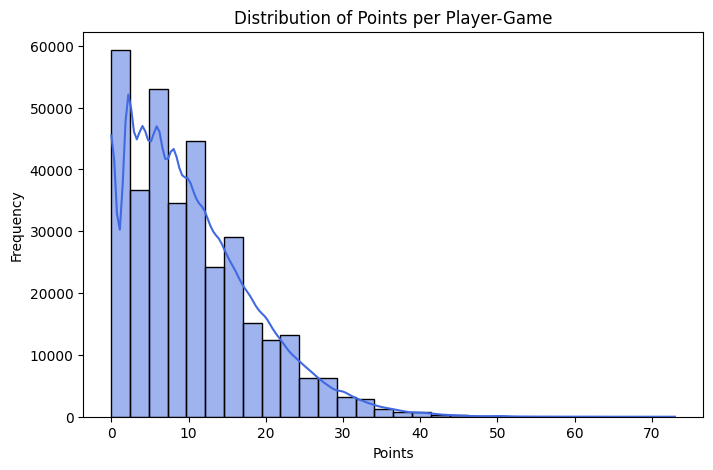

In [189]:
plt.figure(figsize=(8,5))
sns.histplot(active_df['points'], bins=30, kde=True, color='royalblue')
plt.title("Distribution of Points per Player-Game")
plt.xlabel("Points")
plt.ylabel("Frequency")
plt.show()


Even after filtering out players with fewer than 5 minutes and no field goal attempts, the distribution of points per player-game remains heavily skewed toward zero. This reflects the reality of NBA rotations where many role players and bench contributors log meaningful minutes without scoring, focusing instead on defense, playmaking, or rebounding. The long right tail of the distribution captures high-scoring performances, while the concentration at zero highlights the uneven distribution of scoring responsibility across a team.

Now let's compare the scoring based on their position group.

C:\Users\Delabrilliano\AppData\Local\Temp\ipykernel_11700\2315213654.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=active_df, x='Position_group', y='points', palette='Set2')


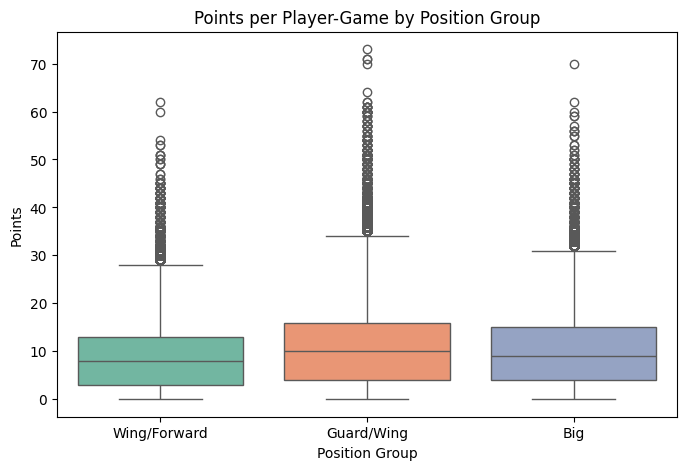

In [190]:
plt.figure(figsize=(8,5))
sns.boxplot(data=active_df, x='Position_group', y='points', palette='Set2')
plt.title("Points per Player-Game by Position Group")
plt.xlabel("Position Group")
plt.ylabel("Points")
plt.show()

Across all seasons, the distribution of points per player-game appears similar across position groups, with medians around 10 points. This suggests that on a per-game basis, no single position group dominates scoring outright.

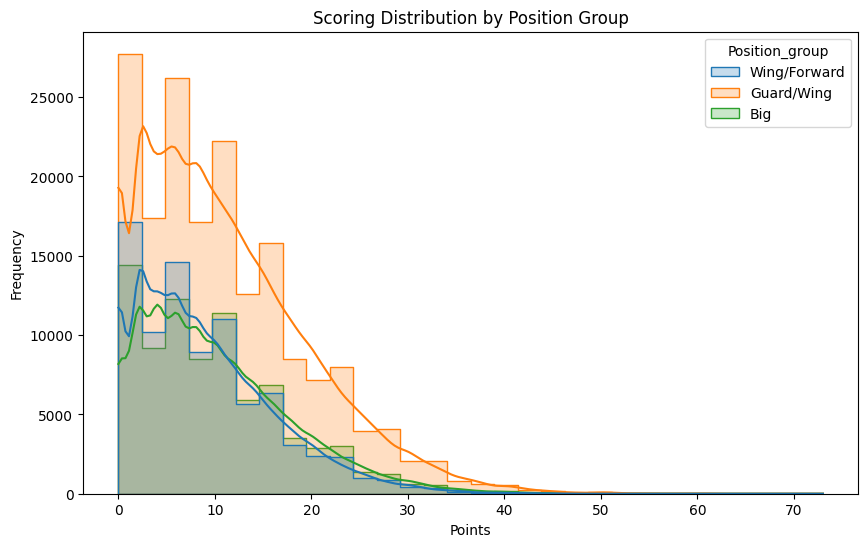

In [191]:
plt.figure(figsize=(10,6))
sns.histplot(data=active_df, x='points', hue='Position_group', bins=30, kde=True, element="step")
plt.title("Scoring Distribution by Position Group")
plt.xlabel("Points")
plt.ylabel("Frequency")
plt.show()

When comparing distributions, Guards/Wings are more likely to contribute modest scoring performances, while Bigs show a more balanced spread. This reflects the increasing reliance on perimeter players for consistent offensive contributions.

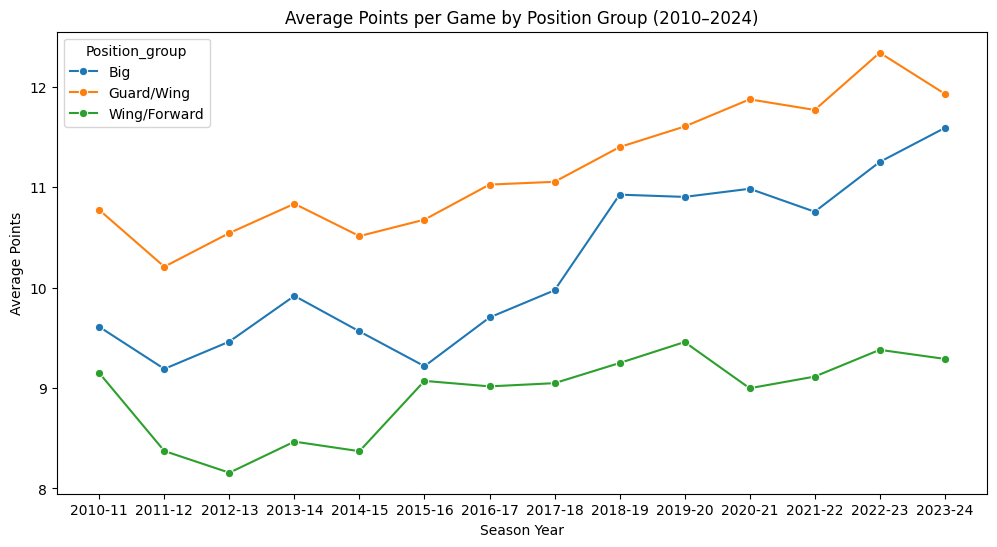

In [192]:
avg_points_by_pos = (
    active_df.groupby(['season_year','Position_group'])['points']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.lineplot(data=avg_points_by_pos, x='season_year', y='points', hue='Position_group', marker="o")
plt.title("Average Points per Game by Position Group (2010–2024)")
plt.xlabel("Season Year")
plt.ylabel("Average Points")
plt.show()

Over time, Guards/Wings have steadily increased their average scoring load, while Bigs and Wing/Forwards have remained flat. This trend aligns with the rise of small-ball strategies, where perimeter players drive offensive production.

To analyze the trend further, we decided to move beyond individual player distributions and examine scoring at the league level. Specifically, we created an aggregate of total points by season and position group. This allows us to calculate each group’s share of overall league scoring and track how that balance has shifted over time. By doing so, we can clearly observe whether Guards/Wings have taken on a larger scoring role compared to Bigs and Wing/Forwards, which directly relates to our investigation of the rise of small-ball lineups

In [193]:
points_share = (
    active_df.groupby(['season_year','Position_group'])['points']
    .sum()
    .reset_index()
)

season_totals = points_share.groupby('season_year')['points'].transform('sum')

points_share['points_pct'] = points_share['points'] / season_totals * 100

<Figure size 1200x600 with 0 Axes>

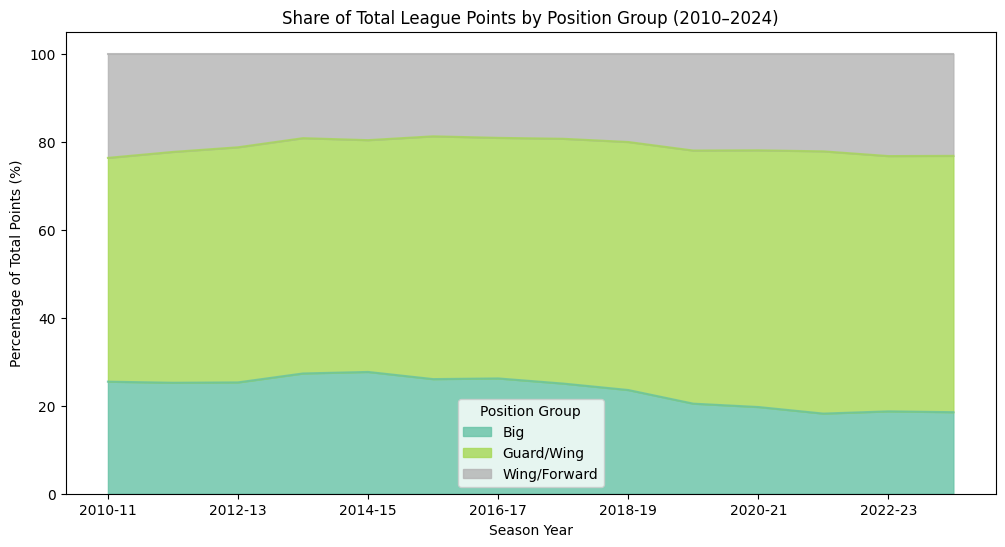

In [194]:
plt.figure(figsize=(12,6))
points_pivot = points_share.pivot(index='season_year', columns='Position_group', values='points_pct')

points_pivot.plot.area(figsize=(12,6), cmap='Set2', alpha=0.8)
plt.title("Share of Total League Points by Position Group (2010–2024)")
plt.xlabel("Season Year")
plt.ylabel("Percentage of Total Points (%)")
plt.legend(title="Position Group")
plt.show()

To quantify the shift toward small-ball, We calculated the percentage of total league points scored by each position group per season. The results show a clear upward trend for Guards/Wings, who now account for a significantly larger share of scoring compared to 2010. Meanwhile, Bigs’ contribution has declined, reflecting the league’s transition toward perimeter-oriented play.

While scoring share highlights which position groups are responsible for putting points on the board, it does not fully capture how coaches allocate playing time. To complement this view, we also examined the distribution of total minutes played by each position group across seasons. By analyzing minutes share, we can see not only who scores more, but also who is trusted to stay on the floor longer — providing a fuller picture of the league’s shift toward small-ball lineups.

In [195]:
minutes_share = (
    active_df.groupby(['season_year','Position_group'])['minutes_played']
    .sum()
    .reset_index()
)

season_minutes = minutes_share.groupby('season_year')['minutes_played'].transform('sum')

minutes_share['minutes_pct'] = minutes_share['minutes_played'] / season_minutes * 100

<Figure size 1200x600 with 0 Axes>

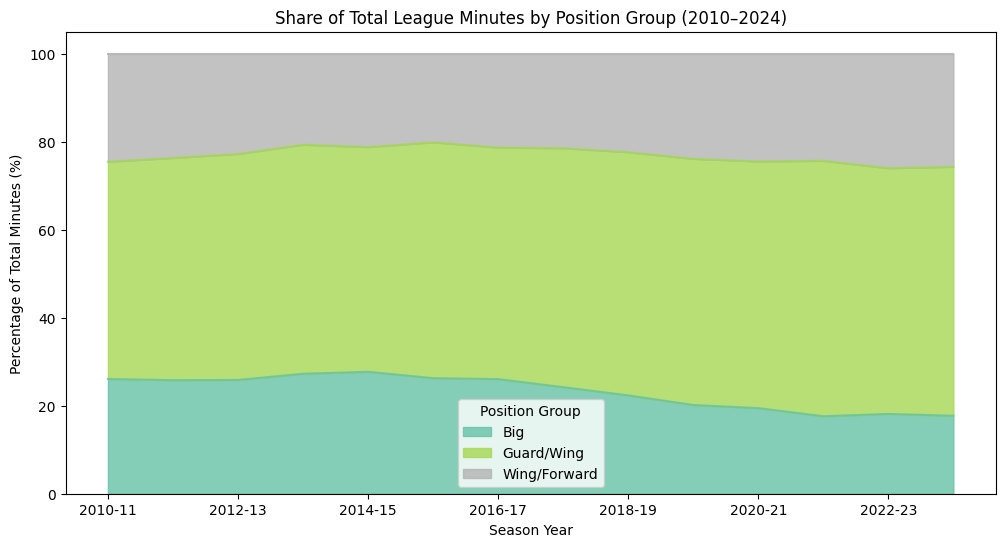

In [196]:
plt.figure(figsize=(12,6))
minutes_pivot = minutes_share.pivot(index='season_year', columns='Position_group', values='minutes_pct')

minutes_pivot.plot.area(figsize=(12,6), cmap='Set2', alpha=0.8)
plt.title("Share of Total League Minutes by Position Group (2010–2024)")
plt.xlabel("Season Year")
plt.ylabel("Percentage of Total Minutes (%)")
plt.legend(title="Position Group")
plt.show()

In addition to scoring share, we also examined the distribution of playing time across position groups. By calculating each group’s share of total league minutes per season, we can see how coaches allocate floor time. The results show that Guards/Wings have steadily increased their share of minutes, while Bigs have declined. This reinforces the scoring trend and provides further evidence of the league’s shift toward small-ball lineups.

While the comparisons of minutes share and points share highlight which position groups are playing more and contributing more total scoring, they do not reveal how efficient each group is when they are actually on the floor. To deepen our analysis, we calculated points per minute for each position group across seasons. This metric allows us to compare scoring efficiency directly, independent of playing time, and provides further insight into the tradeoffs teams make when adopting small-ball strategies.

C:\Users\Delabrilliano\AppData\Local\Temp\ipykernel_11700\2771157803.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['points'].sum() / x['minutes_played'].sum())


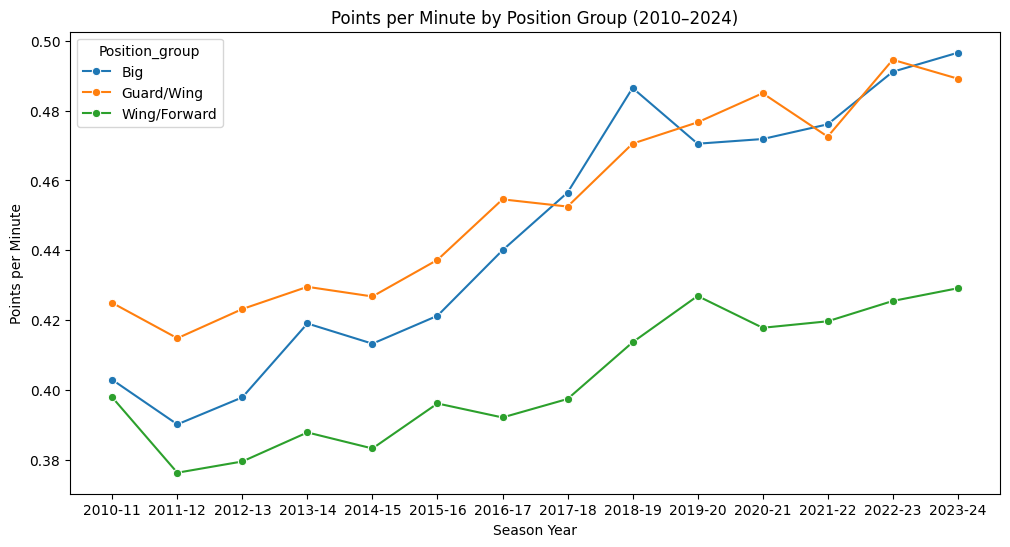

In [197]:
ppm = (
    active_df.groupby(['season_year','Position_group'])
    .apply(lambda x: x['points'].sum() / x['minutes_played'].sum())
    .reset_index(name='points_per_minute')
)

plt.figure(figsize=(12,6))
sns.lineplot(data=ppm, x='season_year', y='points_per_minute', hue='Position_group', marker="o")
plt.title("Points per Minute by Position Group (2010–2024)")
plt.xlabel("Season Year")
plt.ylabel("Points per Minute")
plt.show()

Bigs remain the most efficient scorers on a per-minute basis, but their reduced playing time and role in modern offenses mean that Guards/Wings now dominate total scoring output. This reflects the strategic tradeoff of small-ball: teams prioritize spacing, pace, and versatility over pure efficiency at the rim.

To extend this analysis beyond positional labels, we next examined whether physical attributes themselves, specifically player height, are associated with playing time. If small-ball truly reflects a shift toward smaller, more versatile lineups, we would expect to see shorter and medium-sized players earning more minutes relative to taller players. By analyzing the relationship between height and playing time, we can test whether the trend away from traditional big men is visible not only in scoring roles but also in how coaches allocate floor time.

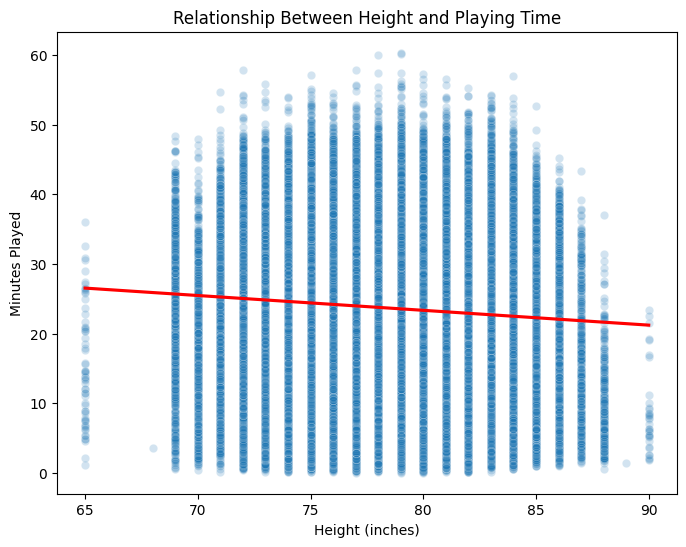

In [198]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=active_df, x='Height', y='minutes_played', alpha=0.2)
sns.regplot(data=active_df, x='Height', y='minutes_played', scatter=False, color='red')
plt.title("Relationship Between Height and Playing Time")
plt.xlabel("Height (inches)")
plt.ylabel("Minutes Played")
plt.show()

The scatterplot reveals a weak but negative relationship between height and playing time, suggesting that taller players are not systematically favored in modern rotations.

While the scatterplot suggests a weak negative relationship between height and playing time, the raw distribution is noisy and difficult to interpret. To make the trend clearer, we grouped players into height categories. Instead of choosing arbitrary cutoffs, we used the 25th and 75th percentiles of the dataset to define “short,” “medium,” and “tall” groups. This ensures that our categories reflect the actual distribution of player sizes in the league, rather than relying on external assumptions.

In [199]:
active_df['Height'].quantile([0.25, 0.5, 0.75])

0.25    76.0
0.50    79.0
0.75    81.0
Name: Height, dtype: float64

In [200]:
q1 = 76
q3 = 81

def height_group(h):
    if h <= q1:
        return "Short"
    elif h <= q3:
        return "Medium"
    else:
        return "Tall"

active_df['height_group'] = active_df['Height'].apply(height_group)

C:\Users\Delabrilliano\AppData\Local\Temp\ipykernel_11700\2535241503.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_df['height_group'] = active_df['Height'].apply(height_group)


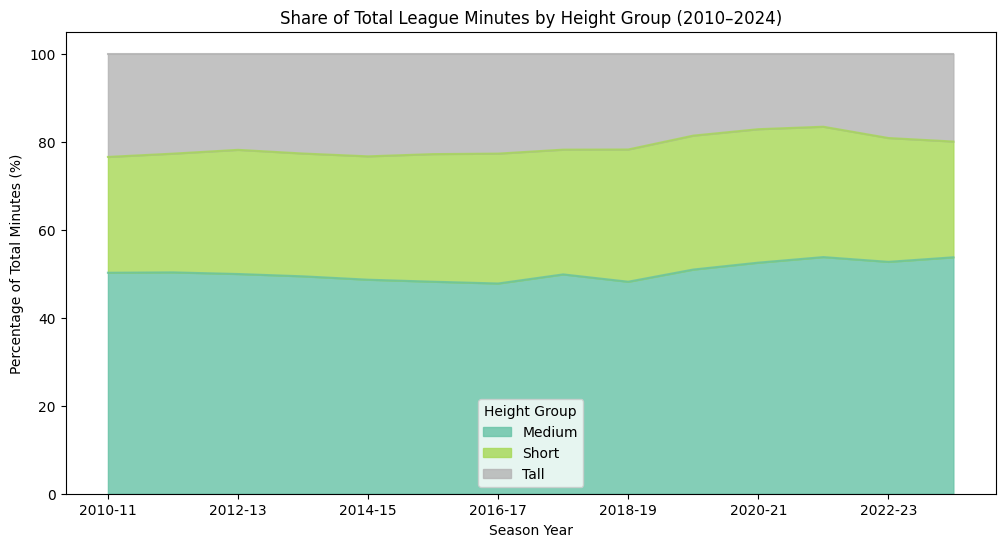

In [201]:
minutes_share_height = (
    active_df.groupby(['season_year','height_group'])['minutes_played']
    .sum()
    .reset_index()
)

season_totals = minutes_share_height.groupby('season_year')['minutes_played'].transform('sum')
minutes_share_height['minutes_pct'] = minutes_share_height['minutes_played'] / season_totals * 100

pivot_height = minutes_share_height.pivot(index='season_year', columns='height_group', values='minutes_pct')

pivot_height.plot.area(figsize=(12,6), alpha=0.8, cmap='Set2')
plt.title("Share of Total League Minutes by Height Group (2010–2024)")
plt.xlabel("Season Year")
plt.ylabel("Percentage of Total Minutes (%)")
plt.legend(title="Height Group")
plt.show()

When looking at league‑wide minutes share, medium‑sized players dominate, while shorter players have gained ground. Taller players, by contrast, have not increased their share, reinforcing the shift away from traditional big‑man lineups.

Together, these visualizations show that height is no longer a reliable predictor of playing time in the NBA. While taller players remain efficient scorers, their average minutes and overall share of league playing time have declined relative to shorter and medium‑sized players. This shift reinforces the small‑ball narrative: coaches increasingly prioritize versatility, spacing, and perimeter skills over traditional size advantages, leading to lineups that are smaller but more dynamic.

Having established that height is no longer a reliable predictor of playing time, the next step is to examine how these shifts manifest in offensive behavior. Playing time allocation tells us who is on the floor, but to gain a broader perspective we also need to understand what those players are doing once they are there. Extending the analysis to shooting patterns allows us to connect changes in lineup composition with the league’s evolving offensive strategies, highlighting how the rise of smaller, more versatile players has reshaped not only minutes distribution but also the geometry of shot selection.

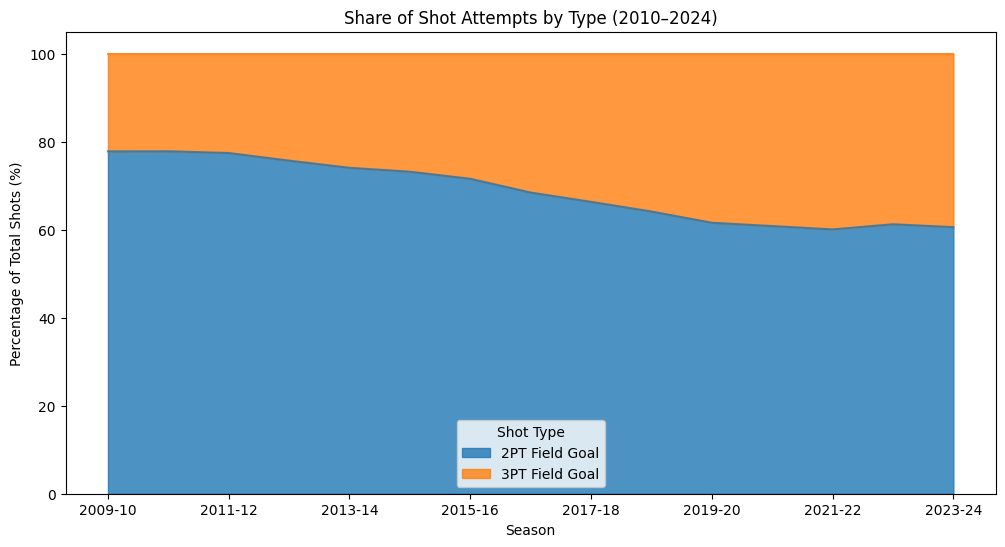

In [202]:
shot_trends = (
    dfth.groupby(['SEASON_2', 'SHOT_TYPE'])
    .size()
    .reset_index(name='attempts')
)

shot_trends['pct'] = shot_trends.groupby('SEASON_2')['attempts'].transform(
    lambda x: x / x.sum() * 100
)

pivot_trends = shot_trends.pivot(index='SEASON_2', columns='SHOT_TYPE', values='pct')

pivot_trends.plot.area(figsize=(12,6), alpha=0.8)
plt.title("Share of Shot Attempts by Type (2010–2024)")
plt.xlabel("Season")
plt.ylabel("Percentage of Total Shots (%)")
plt.legend(title="Shot Type")
plt.show()

The stacked area chart illustrates how shot selection in the NBA has shifted between 2010 and 2024. At the start of the period, the majority of attempts were 2‑point field goals, but their share has steadily declined over time. In contrast, 3‑point field goals have grown from a relatively small portion of total attempts into a central feature of league offenses. This clear crossover highlights a structural change in strategy: teams are increasingly prioritizing perimeter shooting over midrange and interior attempts, laying the foundation for the rise of small‑ball basketball.

The league‑wide trend confirms that shot selection has shifted dramatically over the past decade, with 3‑point attempts steadily replacing 2‑point shots. To understand who is driving this change, it is important to connect these findings with our earlier analysis of playing time by player size. Previously, we showed that shorter and medium‑height players have claimed a growing share of total league minutes. If these same groups are also responsible for a rising share of perimeter shot attempts, it would suggest that the evolution of small‑ball basketball is not only about minutes distribution, but also about a fundamental change in offensive strategy.

In [203]:
active_df.columns

Index(['season_year', 'game_date', 'gameId', 'matchup', 'teamId', 'teamCity',
       'teamName', 'teamTricode', 'teamSlug', 'personId', 'personName',
       'minutes', 'fieldGoalsMade', 'fieldGoalsAttempted',
       'fieldGoalsPercentage', 'threePointersMade', 'threePointersAttempted',
       'threePointersPercentage', 'freeThrowsMade', 'freeThrowsAttempted',
       'freeThrowsPercentage', 'reboundsOffensive', 'reboundsDefensive',
       'reboundsTotal', 'assists', 'steals', 'blocks', 'turnovers',
       'foulsPersonal', 'points', 'plusMinusPoints', 'Height', 'Weight',
       'Position_group', 'minutes_played', 'height_group'],
      dtype='object')

In [204]:
dfth.columns

Index(['SEASON_1', 'SEASON_2', 'TEAM_ID', 'TEAM_NAME', 'PLAYER_ID',
       'PLAYER_NAME', 'POSITION_GROUP', 'POSITION', 'GAME_DATE', 'GAME_ID',
       'HOME_TEAM', 'AWAY_TEAM', 'EVENT_TYPE', 'SHOT_MADE', 'ACTION_TYPE',
       'SHOT_TYPE', 'BASIC_ZONE', 'ZONE_NAME', 'ZONE_ABB', 'ZONE_RANGE',
       'LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'QUARTER', 'MINS_LEFT', 'SECS_LEFT'],
      dtype='object')

In [205]:
dfth.rename(columns={'PLAYER_ID': 'personId'}, inplace=True)

active_keys = active_df[['personId', 'Position_group', 'height_group']].drop_duplicates()

dfth_merged = dfth.merge(active_keys,
                         on=['personId'],
                         how='left')

dfth_merged[['Position_group','height_group']].isna().mean()

Position_group    0.001794
height_group      0.001794
dtype: float64

This missing value is expected since on our previous dataset we took out players who played “garbage minutes” and only included players who actually contributed. As a result, a small fraction of rows in the shot‑level dataset (~0.18% of all shots) do not have corresponding position_group or height_group classifications. Because this proportion is extremely small and represents players outside the scope of our analysis, we will drop these rows to maintain consistency with our earlier filtering criteria. This ensures that all subsequent analyses reflect the same population of meaningful contributors.

In [206]:
dfth_merged = dfth_merged.dropna(subset=['Position_group','height_group'])

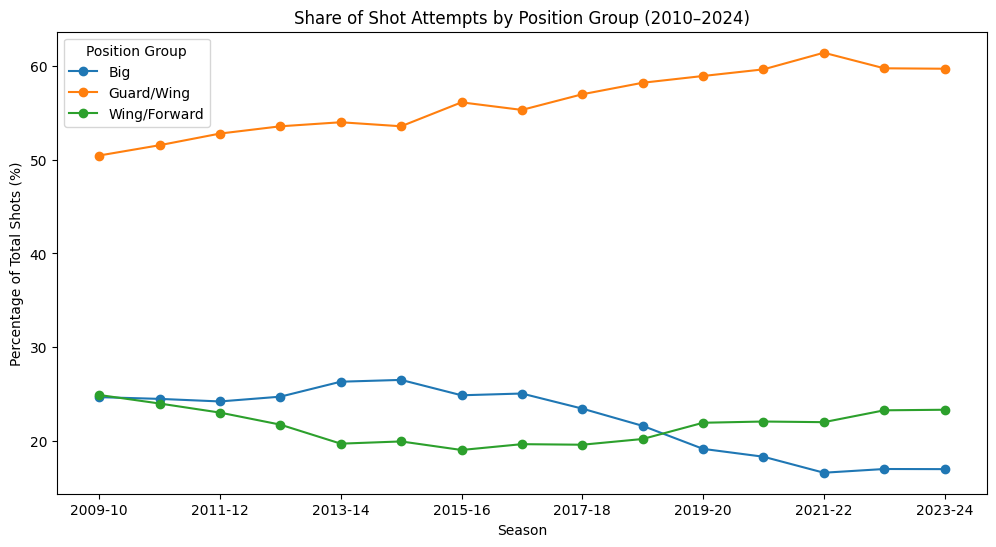

In [207]:
# Group by season and position group
shots_by_pos = (
    dfth_merged.groupby(['SEASON_2', 'Position_group'])
    .size()
    .reset_index(name='attempts')
)

# Convert to percentage share per season
shots_by_pos['pct'] = shots_by_pos.groupby('SEASON_2')['attempts'].transform(
    lambda x: x / x.sum() * 100
)

# Pivot for plotting
pivot_pos = shots_by_pos.pivot(index='SEASON_2', columns='Position_group', values='pct')

# Line chart
pivot_pos.plot(figsize=(12,6), marker='o')
plt.title("Share of Shot Attempts by Position Group (2010–2024)")
plt.xlabel("Season")
plt.ylabel("Percentage of Total Shots (%)")
plt.legend(title="Position Group")
plt.show()


The distribution of shot attempts across position groups highlights a clear structural shift in offensive responsibility. Since 2010, Guards/Wings have steadily increased their share of total shots, rising from around 50% to around 60% of all attempts. In contrast, Bigs peaked in the mid‑2010s but have since declined, while Wings/Forwards have stabilized near 25%. This trend underscores the growing centrality of perimeter‑oriented players in modern offenses, consistent with the league‑wide rise in three‑point shooting.

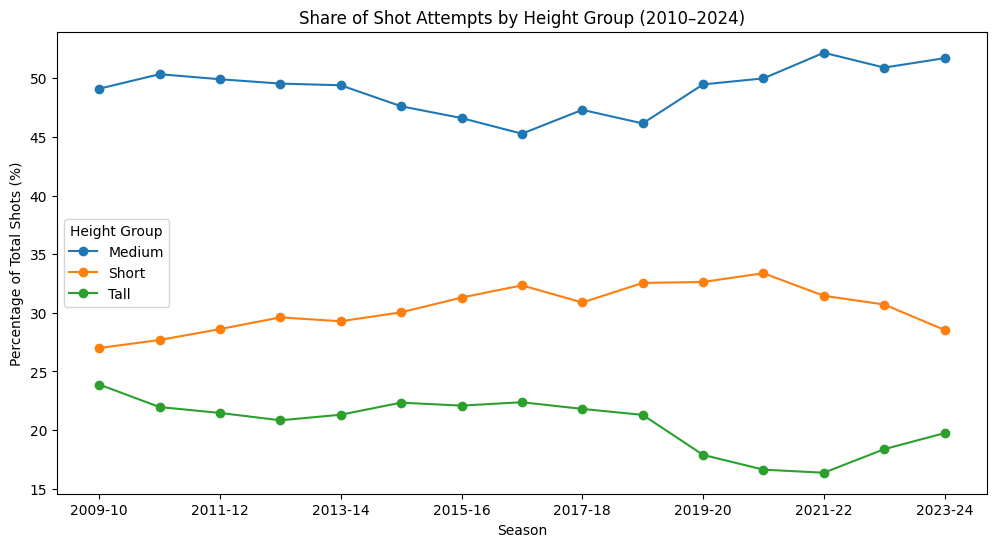

In [208]:
shots_by_height = (
    dfth_merged.groupby(['SEASON_2', 'height_group'])
    .size()
    .reset_index(name='attempts')
)

shots_by_height['pct'] = shots_by_height.groupby('SEASON_2')['attempts'].transform(
    lambda x: x / x.sum() * 100
)

pivot_height = shots_by_height.pivot(index='SEASON_2', columns='height_group', values='pct')

pivot_height.plot(figsize=(12,6), marker='o')
plt.title("Share of Shot Attempts by Height Group (2010–2024)")
plt.xlabel("Season")
plt.ylabel("Percentage of Total Shots (%)")
plt.legend(title="Height Group")
plt.show()


When the same analysis is viewed through the lens of player size, the picture becomes even more striking. Medium‑height players dominate shot creation, accounting for close to half of all attempts throughout the period and surpassing the 50 percent mark in recent seasons. Short players, who once contributed close to 30 percent of attempts, have gradually declined to around 28 percent, while tall players consistently represent the smallest share of shots. Taken together, these results suggest that the shift toward perimeter play is not simply about shorter players taking more shots, but rather about the rise of medium‑sized, versatile guards and wings who can both handle the ball and stretch the floor. Tall players remain involved, but their role has narrowed to rim finishing and selective perimeter shooting rather than high‑volume creation.

**Heatmap Comparison of 2010-2011 and 2023-2024**

In [209]:
def draw_court(ax=None, color="black", lw=2):
    if ax is None:
        ax = plt.gca()

    # Hoop
    hoop = plt.Circle((0, 4), radius=0.75, linewidth=lw, color=color, fill=False)

    # Backboard
    backboard = plt.Rectangle((-3, 4), 6, 0.5, linewidth=lw, color=color)

    # Paint (outer key)
    outer_box = plt.Rectangle((-8, 0), 16, 19, linewidth=lw, color=color, fill=False)

    # Free throw circle
    ft_circle = plt.Circle((0, 19), 6, linewidth=lw, color=color, fill=False)

    # Three-point arc
    three_arc = plt.Circle((0, 4), 23.75, linewidth=lw, color=color, fill=False)

    for element in [hoop, backboard, outer_box, ft_circle, three_arc]:
        ax.add_patch(element)

    return ax


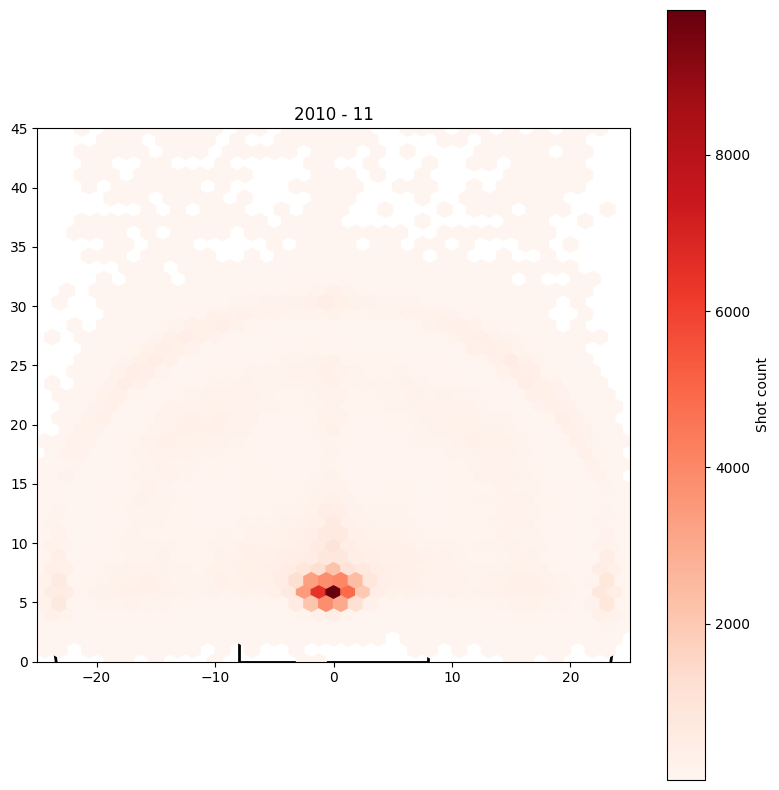

In [210]:
shots = dfth_merged[dfth_merged['SEASON_2'] == '2010-11']

plt.figure(figsize=(8,8))
draw_court()

hb = plt.hexbin(
    shots['LOC_X'], shots['LOC_Y'],
    gridsize=40, cmap="Reds",
    extent=( -25, 25, 0, 45 ),
    mincnt=1
)
plt.colorbar(hb, label="Shot count")

plt.xlim(-25, 25)
plt.ylim(0, 45)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("2010 - 11")
plt.tight_layout()
plt.show()

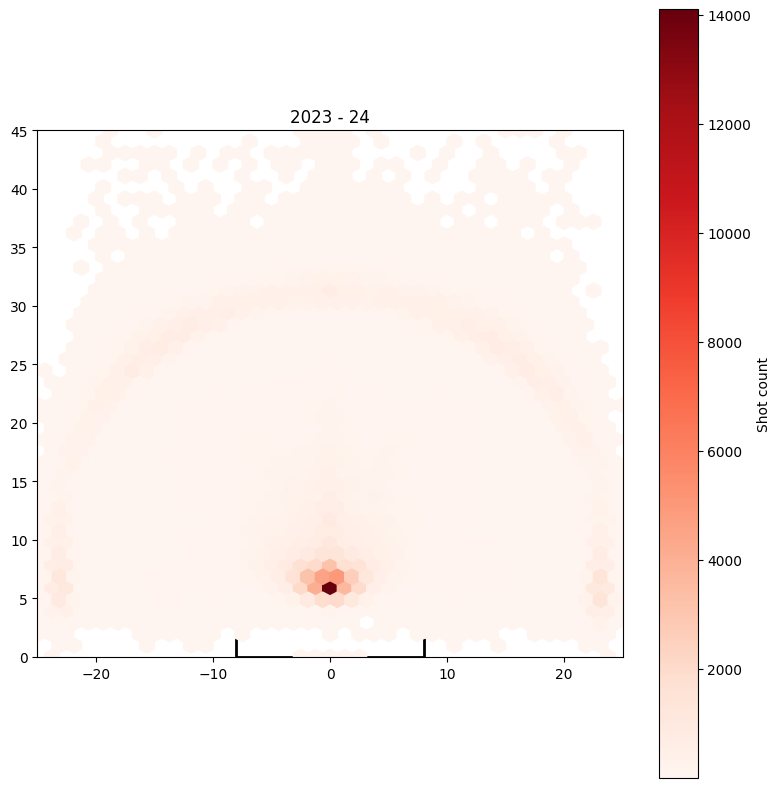

In [211]:
shots = dfth_merged[dfth_merged['SEASON_2'] == '2023-24']


plt.figure(figsize=(8,8))
draw_court()

hb = plt.hexbin(
    shots['LOC_X'], shots['LOC_Y'],
    gridsize=40, cmap="Reds",
    extent=( -25, 25, 0, 45 ),
    mincnt=1
)
plt.colorbar(hb, label="Shot count")

plt.xlim(-25, 25)
plt.ylim(0, 45)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("2023 - 24")
plt.tight_layout()
plt.show()

**Heatmap Comparison of 2010-2011 and 2023-2024**

In [212]:
def draw_court(ax=None, color="black", lw=2):
    if ax is None:
        ax = plt.gca()

    # Hoop
    hoop = plt.Circle((0, 4), radius=0.75, linewidth=lw, color=color, fill=False)

    # Backboard
    backboard = plt.Rectangle((-3, 4), 6, 0.5, linewidth=lw, color=color)

    # Paint (outer key)
    outer_box = plt.Rectangle((-8, 0), 16, 19, linewidth=lw, color=color, fill=False)

    # Free throw circle
    ft_circle = plt.Circle((0, 19), 6, linewidth=lw, color=color, fill=False)

    # Three-point arc
    three_arc = plt.Circle((0, 4), 23.75, linewidth=lw, color=color, fill=False)

    for element in [hoop, backboard, outer_box, ft_circle, three_arc]:
        ax.add_patch(element)

    return ax


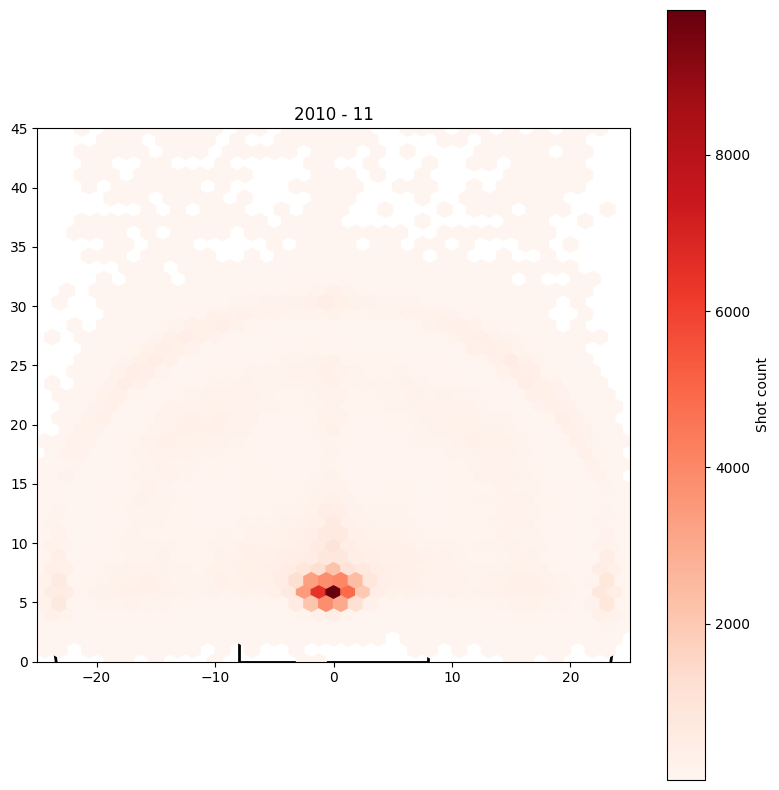

In [213]:
shots = dfth_merged[dfth_merged['SEASON_2'] == '2010-11']

plt.figure(figsize=(8,8))
draw_court()

hb = plt.hexbin(
    shots['LOC_X'], shots['LOC_Y'],
    gridsize=40, cmap="Reds",
    extent=( -25, 25, 0, 45 ),
    mincnt=1
)
plt.colorbar(hb, label="Shot count")

plt.xlim(-25, 25)
plt.ylim(0, 45)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("2010 - 11")
plt.tight_layout()
plt.show()

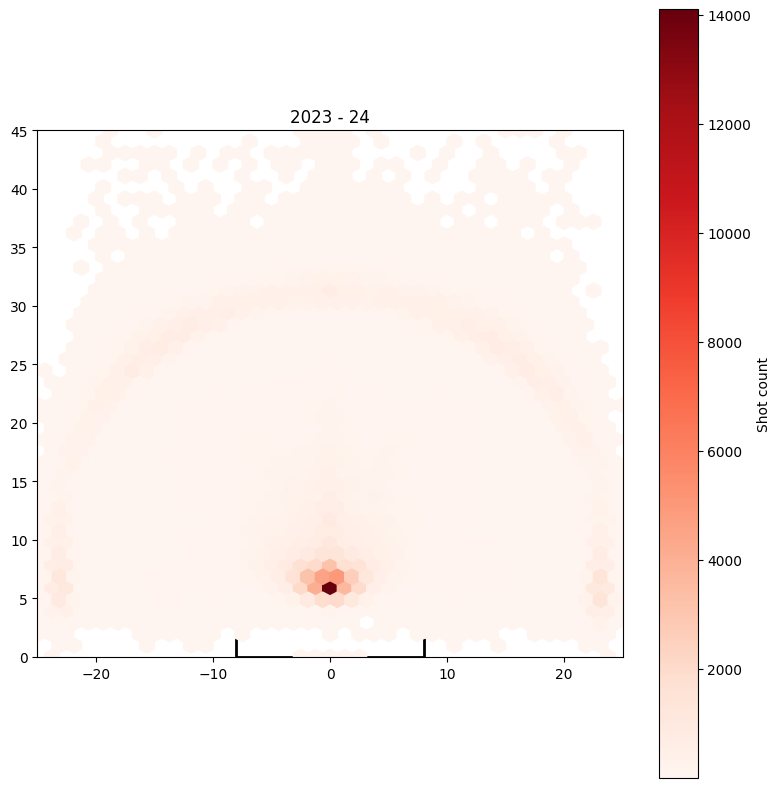

In [214]:
shots = dfth_merged[dfth_merged['SEASON_2'] == '2023-24']


plt.figure(figsize=(8,8))
draw_court()

hb = plt.hexbin(
    shots['LOC_X'], shots['LOC_Y'],
    gridsize=40, cmap="Reds",
    extent=( -25, 25, 0, 45 ),
    mincnt=1
)
plt.colorbar(hb, label="Shot count")

plt.xlim(-25, 25)
plt.ylim(0, 45)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("2023 - 24")
plt.tight_layout()
plt.show()

# CONCLUSION

Taken together, the analyses reveal how profoundly the NBA has transformed between 2010 and 2024. At the individual level, scoring remains highly skewed, with a small number of players carrying the bulk of offensive responsibility while many others contribute in non‑scoring roles. Yet when viewed through the lens of position and player size, clear structural shifts emerge. Guards and wings have steadily increased both their scoring load and their share of total minutes, while bigs have declined in both respects despite remaining the most efficient scorers on a per‑minute basis. This reflects the strategic tradeoff of modern basketball: teams prioritize spacing, pace, and versatility over pure efficiency at the rim.

Height‑based analysis reinforces this picture. Medium‑sized players have become the dominant creators, surpassing both shorter guards and taller bigs in shot attempts and playing time. Short players continue to play heavy minutes, but their relative share of shot creation has declined, while tall players are increasingly confined to specialized roles around the basket. The result is a league where height alone no longer dictates opportunity; instead, adaptability and perimeter skills determine who stays on the floor.

Finally, the evolution of shot selection underscores the broader transformation. The steady decline of midrange and interior attempts, coupled with the dramatic rise of three‑point shooting, has redefined offensive strategy. This shift is not only about where shots are taken but also about who is taking them: perimeter‑oriented guards and wings, especially medium‑sized players, now drive the majority of offensive creation.

In sum, the rise of small‑ball basketball is not a single trend but an interconnected set of changes in scoring distribution, positional roles, playing time, efficiency, and shot selection. The modern NBA is built around versatile perimeter players who can stretch the floor and create offense from multiple zones, supported by bigs in narrower roles and shorter guards in complementary ones. What emerges is a game that is smaller, faster, and more dynamic — a structural redefinition of how basketball is played at its highest level.